# 🛒 Analyse du dataset US Superstore
**Visualisation des données avec Matplotlib et Seaborn**

Ce notebook couvre :
1. Préparation et exploration des données
2. Visualisations avec Matplotlib (tendances des ventes, répartition géographique)
3. Visualisations avec Seaborn (top produits, relation profit/remise)
4. Analyse comparative Matplotlib vs Seaborn

---
## Partie 1 — Préparation des données

In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns



In [2]:
# Chargement du fichier .xls (format legacy → moteur xlrd obligatoire)
df = pd.read_excel('US Superstore data.xls', engine='xlrd')

# Aperçu rapide du dataset
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head()

Dimensions : 9994 lignes × 21 colonnes


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Informations générales sur les types de colonnes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [4]:
# ── Nettoyage et prétraitement ──────────────────────────────────────────────

# 1. Vérification des valeurs manquantes
valeurs_manquantes = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(valeurs_manquantes[valeurs_manquantes > 0] if valeurs_manquantes.any() else "Aucune valeur manquante ✓")

# 2. Vérification des doublons
nb_doublons = df.duplicated().sum()
print(f"\nNombre de doublons : {nb_doublons}")

# 3. Extraction de l'année à partir de la date de commande
#    → nécessaire pour les analyses temporelles (Partie 2)
df['Année'] = df['Order Date'].dt.year

# 4. Résumé statistique des colonnes numériques
print("\nStatistiques descriptives :")
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

Valeurs manquantes par colonne :
Aucune valeur manquante ✓

Nombre de doublons : 0

Statistiques descriptives :


,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


**Observations — Préparation des données**

- Le dataset contient **9 994 commandes** et **21 colonnes** sans aucune valeur manquante ni doublon : il est prêt à l'emploi.
- Toutes les commandes proviennent des **États-Unis** ; la colonne `Country` n'apporte pas de valeur discriminante pour une carte multi-pays. La visualisation géographique se fera donc par **État**.
- Les ventes couvrent les années **2014 à 2017**.
- La remise (`Discount`) varie de 0 à 0,8 (80 %), ce qui peut fortement impacter le profit.

---
## Partie 2 — Visualisation avec Matplotlib

### 2.1 Graphique linéaire — Tendances des ventes au fil des ans

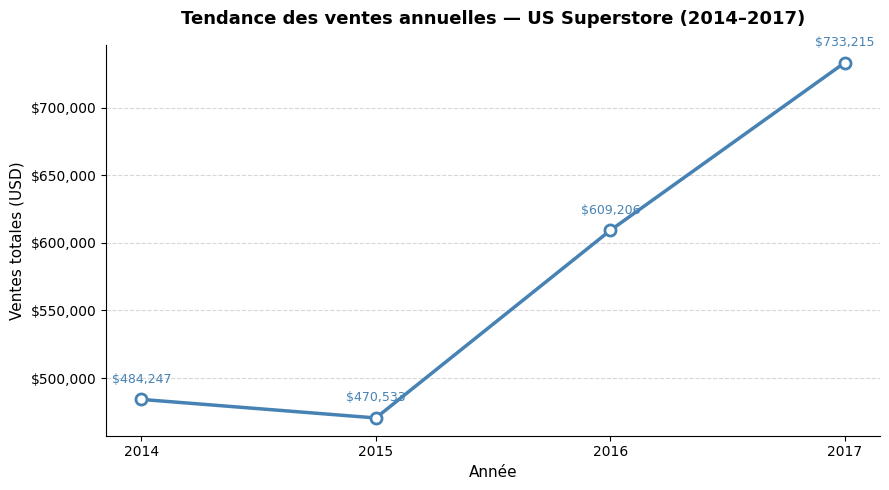

In [5]:
# ── Préparation : ventes totales par année ───────────────────────────────────
ventes_par_annee = df.groupby('Année')['Sales'].sum().reset_index()
ventes_par_annee.columns = ['Année', 'Ventes_Totales']

# ── Tracé du graphique linéaire ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    ventes_par_annee['Année'],
    ventes_par_annee['Ventes_Totales'],
    marker='o',        # cercle sur chaque point de données
    linewidth=2.5,
    color='steelblue',
    markersize=8,
    markerfacecolor='white',
    markeredgewidth=2
)

# Annotation de la valeur au-dessus de chaque point
for _, row in ventes_par_annee.iterrows():
    ax.annotate(
        f"${row['Ventes_Totales']:,.0f}",
        xy=(row['Année'], row['Ventes_Totales']),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        color='steelblue'
    )

# Mise en forme de l'axe Y en format monétaire
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Axe X : uniquement les 4 années entières
ax.set_xticks(ventes_par_annee['Année'])

ax.set_title('Tendance des ventes annuelles — US Superstore (2014–2017)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Année', fontsize=11)
ax.set_ylabel('Ventes totales (USD)', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Observations — Tendances des ventes**

- Les ventes progressent **chaque année** : de \$484 K en 2014 à \$733 K en 2017, soit une croissance de **+51 %** sur 4 ans.
- La progression est particulièrement marquée entre **2016 et 2017** (+20 %).
- Une légère baisse est observable entre **2014 et 2015** (–3 %), avant la reprise en 2016.

### 2.2 Carte interactive — Répartition des ventes par État

In [6]:
# ── Préparation : ventes totales par État ────────────────────────────────────
#    Note : toutes les commandes sont aux États-Unis → visualisation par État
ventes_par_etat = df.groupby('State')['Sales'].sum().reset_index()
ventes_par_etat.columns = ['État', 'Ventes_Totales']
ventes_par_etat = ventes_par_etat.sort_values('Ventes_Totales', ascending=False)

# Affichage du top 5 pour vérification
print("Top 5 États par ventes :")
print(ventes_par_etat.head())

Top 5 États par ventes :
            État  Ventes_Totales
3     California     457687.6315
30      New York     310876.2710
41         Texas     170188.0458
45    Washington     138641.2700
36  Pennsylvania     116511.9140


In [ ]:
# ── Carte choroplèthe des ventes par État avec Matplotlib ────────────────────
#    On utilise un graphique à barres horizontales classé comme alternative
#    à une vraie carte géographique (qui nécessite geopandas/shapefile)

top15_etats = ventes_par_etat.head(15)

fig, ax = plt.subplots(figsize=(10, 7))

# Palette de couleurs dégradée selon le rang
couleurs = plt.cm.Blues_r(
    [i / len(top15_etats) * 0.6 + 0.2 for i in range(len(top15_etats))]
)

barres = ax.barh(
    top15_etats['État'],
    top15_etats['Ventes_Totales'],
    color=couleurs,
    edgecolor='white',
    height=0.7
)

# Étiquettes de valeur à droite de chaque barre
for barre in barres:
    largeur = barre.get_width()
    ax.text(
        largeur + 2000,
        barre.get_y() + barre.get_height() / 2,
        f'${largeur:,.0f}',
        va='center',
        fontsize=8.5,
        color='#333333'
    )

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.invert_yaxis()  # État n°1 en haut
ax.set_title('Répartition des ventes par État — Top 15', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Ventes totales (USD)', fontsize=11)
ax.set_ylabel('État', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Observations — Répartition géographique**

- La **Californie** domine largement avec plus de \$457 K de ventes, suivie de **New York** (\$310 K) et du **Texas** (\$170 K).
- Ces 3 États concentrent à eux seuls une part majeure du chiffre d'affaires total.
- Les États moins peuplés (Wyoming, North Dakota…) ne figurent pas dans le top 15, ce qui reflète la concentration commerciale sur les côtes Est et Ouest.

---
## Partie 3 — Visualisation avec Seaborn

### 3.1 Graphique à barres — Top 10 produits les plus vendus

In [7]:
# ── Préparation : top 10 produits par chiffre d'affaires ────────────────────
top10_produits = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10_produits.columns = ['Produit', 'Ventes']

# Troncature des noms longs pour l'affichage (max 45 caractères)
top10_produits['Produit_Court'] = top10_produits['Produit'].str[:45] + '...'

C:\Users\ndev\AppData\Local\Temp\ipykernel_13684\1056232490.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


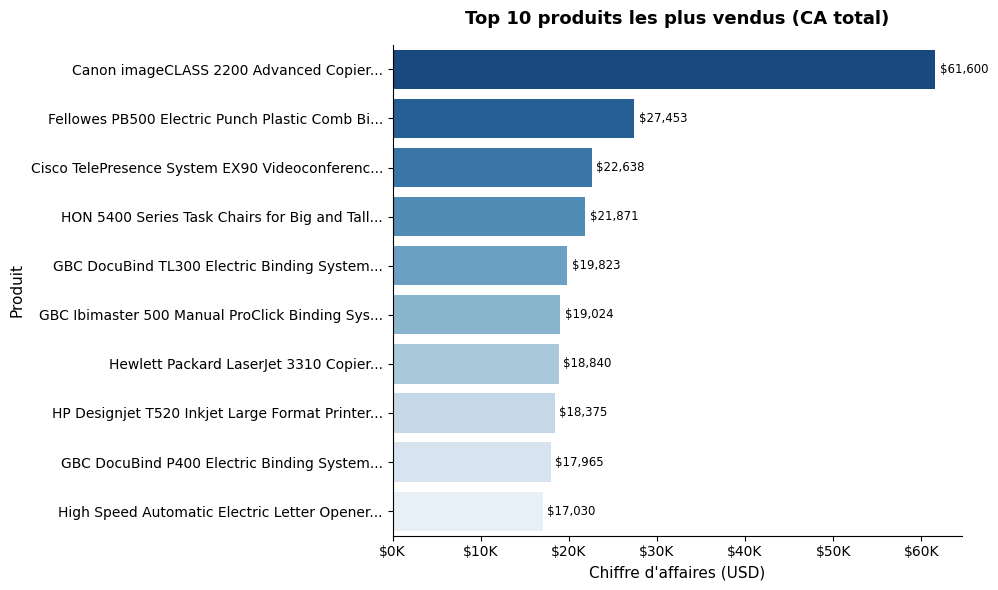

In [8]:
# ── Graphique à barres Seaborn ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top10_produits,
    x='Ventes',
    y='Produit_Court',
    palette='Blues_r',  # dégradé du plus vendu au moins vendu
    ax=ax
)

# Étiquettes de valeur
for barre in ax.patches:
    ax.text(
        barre.get_width() + 500,
        barre.get_y() + barre.get_height() / 2,
        f"${barre.get_width():,.0f}",
        va='center',
        fontsize=8.5
    )

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Top 10 produits les plus vendus (CA total)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Chiffre d\'affaires (USD)', fontsize=11)
ax.set_ylabel('Produit', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Observations — Top 10 produits**

- Le **Canon imageCLASS 2200 Advanced Copier** est de loin le produit le plus vendu avec \$61 600, devançant le deuxième produit de plus du double.
- Les produits du top 10 appartiennent majoritairement à la catégorie **Technology** (copieurs, imprimantes, vidéoconférence).
- La présence de plusieurs machines à relier (GBC, Fellowes) indique une forte demande en fournitures de bureau.

### 3.2 Nuage de points — Relation entre Profit et Remise

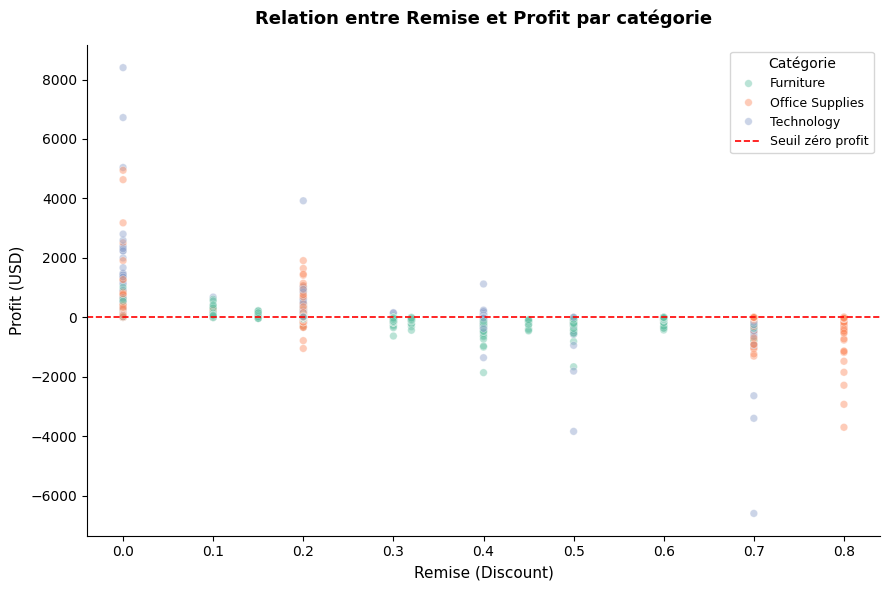

In [9]:
# ── Nuage de points Seaborn avec coloration par catégorie ───────────────────
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Category',       # une couleur par catégorie de produit
    alpha=0.45,           # transparence pour voir les zones denses
    s=30,                 # taille des points
    palette='Set2',
    ax=ax
)

# Ligne de référence à profit = 0 (seuil de rentabilité)
ax.axhline(0, color='red', linewidth=1.2, linestyle='--', label='Seuil zéro profit')

ax.set_title('Relation entre Remise et Profit par catégorie', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Remise (Discount)', fontsize=11)
ax.set_ylabel('Profit (USD)', fontsize=11)
ax.legend(title='Catégorie', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Observations — Profit vs Remise**

- Il existe une **corrélation négative claire** : plus la remise augmente, plus le profit tend à diminuer, voire à devenir négatif.
- Sans remise (Discount = 0), les profits sont largement positifs pour toutes les catégories.
- À partir de **30–40 % de remise**, de nombreuses commandes génèrent des **pertes** (profit < 0).
- La catégorie **Furniture** est la plus touchée par les remises élevées avec des pertes importantes.
- **Technology** maintient globalement de meilleurs profits, même avec des remises modérées.

---
## Partie 4 — Analyse comparative : Matplotlib vs Seaborn

| Critère | Matplotlib | Seaborn |
|---|---|---|
| **Facilité d'utilisation** | Verbeux : chaque détail (couleurs, étiquettes, grille) se configure manuellement | Concis : graphiques statistiques élaborés en quelques lignes |
| **Graphiques statistiques** | Nécessite du code supplémentaire | Natif : hue, palette, estimation de densité intégrés |
| **Personnalisation fine** | Très haute : contrôle total sur chaque élément | Bonne, mais moins granulaire |
| **Lisibilité du code** | Code plus long mais explicite | Code court et lisible |
| **Cas d'usage idéal** | Graphiques sur mesure, annotations complexes, cartes | EDA rapide, comparaisons multi-groupes, distributions |
| **Intégration pandas** | Bonne (via `ax`) | Excellente (accepte directement un DataFrame) |

**Conclusion :** Seaborn est plus efficace pour l'**exploration rapide** des données (EDA) et les visualisations statistiques avec groupes. Matplotlib offre un **contrôle total** et reste indispensable pour des graphiques très personnalisés ou des mises en page complexes. En pratique, les deux sont souvent utilisés **conjointement** : Seaborn pour le graphique de base, Matplotlib pour affiner les détails.